# Image Classification - Convolutional Neural Networks (CNNs)

### Import libraries and modules

In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile
import numpy as np
import cv2

from google.colab import drive
from google.colab.patches import cv2_imshow
# tensorflow imports, we will be using the Sequential API for building our CNN model
from tensorflow.keras.models import Sequential
# convolutional layers, pooling layers, flatten layer and dense layers for building our CNN model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
# for data augmentation and preprocessing of our image data before feeding it to the CNN model for training and testing our model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
# for saving our trained model weights after training our CNN model on our image data and for loading the saved model weights for making predictions on new image data using our trained CNN model
from keras.models import save_model

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

tf.__version__

'2.20.0'

### Loading image dataset

In [2]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
path = '/content/drive/My Drive/Colab Notebooks/Computer Vision Masterclass_Udemy/Training_Material/Datasets/homer_bart_2.zip'
zip_object = zipfile.ZipFile(file=path, mode='r')
zip_object.extractall('./')
zip_object.close()

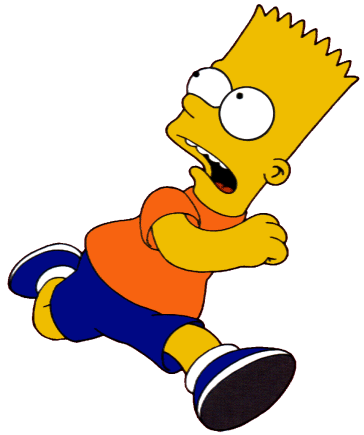

In [4]:
tf.keras.preprocessing.image.load_img('/content/homer_bart_2/training_set/bart/bart100.bmp')

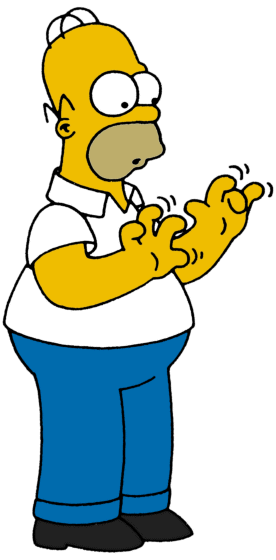

In [5]:
tf.keras.preprocessing.image.load_img('/content/homer_bart_2/training_set/homer/homer100.bmp')

### Train & Test Image dataset

In [6]:
# We can configure some parameters to make modifications to the original images, 
# which is very useful when we have few images of each class. 
# As you can see here, there are many other parameters that can be configured. 
# Using this function, in addition to the original images, we will also have new images with application of these pre-processing
training_generator = ImageDataGenerator(
    rescale=1./255, # This parameter will rescale the pixel values of the images to be between 0 and 1, which is a common practice in deep learning to improve the performance of the model.
    rotation_range=7, # This parameter will randomly rotate the images by a certain degree, which helps the model to be invariant to rotations.
    horizontal_flip=True, # This parameter will randomly flip the images horizontally, which helps the model to be invariant to horizontal flips.
    zoom_range=0.2 # This parameter will randomly zoom into the images, which helps the model to be invariant to zooming.
)

# Indicates that the images will be accessed every eight. As we have few images, we put this small value.
# As the name suggests, this parameter will mix the images, 
# they will be accessed in a completely random order to prevent the neural network 
# from memorizing the order of the images. Otherwise, the neural network could 
# learn the order of the images and not their features
train_dataset = training_generator.flow_from_directory(
    '/content/homer_bart_2/training_set', # this is the path to the training set directory, which contains two subdirectories, one for each class (homer and bart)
    target_size = (64, 64), # this parameter will resize the images to be 64x64 pixels, which is a common practice in deep learning to reduce the computational cost of training the model
    batch_size = 8, # this parameter will indicate how many images will be accessed at a time, which is a common practice in deep learning to reduce the computational cost of training the model
    class_mode = 'categorical', # this parameter will indicate that the labels of the images are in categorical format, which is a common practice in deep learning for multi-class classification problems
    shuffle = True # this parameter will indicate that the images will be accessed in a random order, which is a common practice in deep learning to prevent the model from memorizing the order of the images
)

Found 215 images belonging to 2 classes.


In [7]:
train_dataset.classes

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], dtype=int32)

In [8]:
train_dataset.class_indices

{'bart': 0, 'homer': 1}

In [9]:
# To test, we set this parameter to FALSE because when testing, 
# the order of the images makes no difference. 
# If we leave the value equals TRUE, we will not be able to associate the 
# predictions with the expected outputs
test_generator = ImageDataGenerator(rescale=1./255)

test_dataset = test_generator.flow_from_directory('/content/homer_bart_2/test_set',
                                                     target_size = (64, 64),
                                                     batch_size = 1,
                                                     class_mode = 'categorical',
                                                     shuffle = False)

Found 54 images belonging to 2 classes.


### Build & Train - neural network

In [10]:
64 * 64
(6272 + 2) / 2

3137.0

In [11]:
network = Sequential()
network.add(Conv2D(32, (3,3), input_shape = (64,64,3), activation='relu'))
network.add(MaxPooling2D(pool_size=(2,2)))

network.add(Conv2D(32, (3,3), activation='relu'))
network.add(MaxPooling2D(pool_size=(2,2)))

network.add(Conv2D(32, (3,3), activation='relu'))
network.add(MaxPooling2D(pool_size=(2,2)))


network.add(Flatten())

network.add(Dense(units = 3137, activation='relu'))
network.add(Dense(units = 3137, activation='relu'))
network.add(Dense(units = 2, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [12]:
14 * 14 * 32

6272

In [13]:
network.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3137)           │     3,616,961 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3137)           │     9,843,906 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │         6,276 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,486,535 (51.45 MB)

 Trainable params: 13,486,535 (51.45 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
network.compile(optimizer='Adam', loss='categorical_crossentropy', metrics = ['accuracy'])

In [17]:
history = network.fit(train_dataset, epochs=50, validation_data=test_dataset)

Epoch 1/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 12s 356ms/step - accuracy: 0.5256 - loss: 0.9433 - val_accuracy: 0.5185 - val_loss: 0.6583
Epoch 2/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 7s 267ms/step - accuracy: 0.6698 - loss: 0.6170 - val_accuracy: 0.5185 - val_loss: 0.7330
Epoch 3/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 10s 359ms/step - accuracy: 0.7163 - loss: 0.5380 - val_accuracy: 0.8519 - val_loss: 0.4085
Epoch 4/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 7s 258ms/step - accuracy: 0.7814 - loss: 0.4907 - val_accuracy: 0.8148 - val_loss: 0.3710
Epoch 5/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 9s 327ms/step - accuracy: 0.8140 - loss: 0.4232 - val_accuracy: 0.7593 - val_loss: 0.4240
Epoch 6/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 8s 279ms/step - accuracy: 0.8279 - loss: 0.3855 - val_accuracy: 0.7593 - val_loss: 0.5684
Epoch 7/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 10s 270ms/step - accuracy: 0.8744 - loss: 0.3156 - val_accuracy: 0.9259 - val_loss: 0.2888
Epoch 8/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 9s 338ms/step - accuracy: 0.8372 - loss: 0.3699 - val_accuracy:

### Evaluate the model - Predictions, Accuracy, Confusion Matrix, Classification Report

In [18]:
history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

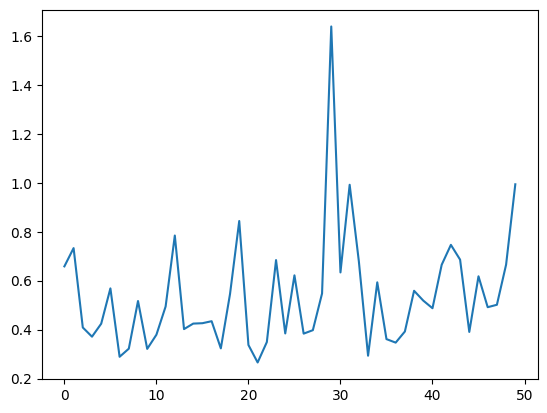

In [19]:
plt.plot(history.history['val_loss']);

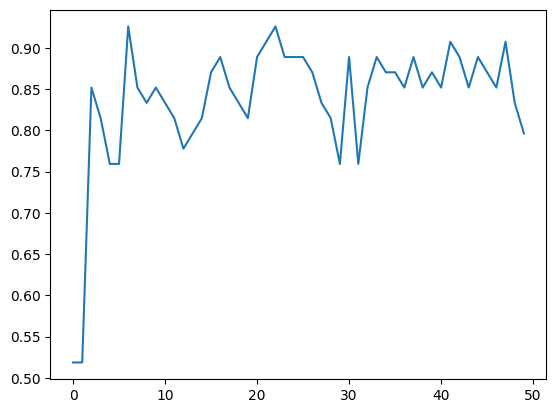

In [20]:
plt.plot(history.history['val_accuracy']);

In [21]:
test_dataset.class_indices

{'bart': 0, 'homer': 1}

In [22]:
predictions = network.predict(test_dataset)
predictions

54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step


array([[1.0000000e+00, 4.3402322e-19],
       [1.0000000e+00, 5.2635075e-14],
       [8.6100829e-01, 1.3899176e-01],
       [1.0000000e+00, 4.6448425e-18],
       [1.0000000e+00, 1.3553198e-18],
       [1.0000000e+00, 1.0844757e-15],
       [9.9999988e-01, 1.1507977e-07],
       [9.9992764e-01, 7.2368253e-05],
       [9.9826860e-01, 1.7313309e-03],
       [9.9955243e-01, 4.4749898e-04],
       [1.0000000e+00, 8.4119973e-09],
       [1.0000000e+00, 1.4348821e-10],
       [9.8360521e-01, 1.6394788e-02],
       [9.9999976e-01, 1.9103081e-07],
       [1.0000000e+00, 1.4285584e-09],
       [1.0000000e+00, 8.2113604e-22],
       [9.9999654e-01, 3.4811917e-06],
       [1.0000000e+00, 1.8472764e-15],
       [9.8281938e-01, 1.7180637e-02],
       [1.0000000e+00, 1.8866509e-16],
       [9.9999964e-01, 3.5287286e-07],
       [1.0000000e+00, 1.9517521e-12],
       [9.9999225e-01, 7.7864725e-06],
       [1.5168330e-01, 8.4831673e-01],
       [1.0000000e+00, 8.8817408e-16],
       [9.9999964e-01, 3.

In [23]:
# The output of the predict function is a 2D array where each row corresponds to an image in the test dataset and each column corresponds to a class (homer or bart).
# The values in the array represent the predicted probabilities for each class.
# To get the predicted class labels, we can use the argmax function to find the index of the maximum value in each row, which corresponds to the predicted class label for each image.
# For example, if the predicted probabilities for an image are [0.1, 0.9], then the predicted class label would be 1 (bart) because the maximum value is 0.9 and it corresponds to the second column (bart).
# We can also use the argmax function to get the predicted class labels for all the images in the test dataset at once, which will give us a 1D array of predicted class labels.
# To get the predicted class labels, we can use the argmax function to find the index of the maximum value in each row, which corresponds to the predicted class label for each image.
predictions = np.argmax(predictions, axis = 1)
predictions

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1,
       0, 0, 0, 1, 1, 0, 0, 0, 1, 1])

In [24]:
test_dataset.classes

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1], dtype=int32)

In [25]:
# identifies these bart images, it is correct 68% of the time
# We can conclude that this neural network is better for classifying bart images, as we saw in the confusion matrix because the accuracy is 68% and the confusion matrix shows that the model is better at classifying bart images than homer images.
# The accuracy score is calculated by comparing the predicted class labels with the true class labels of the test dataset.
accuracy_score(test_dataset.classes, predictions)

0.7962962962962963

In [26]:
test_dataset.class_indices

{'bart': 0, 'homer': 1}

<Axes: >

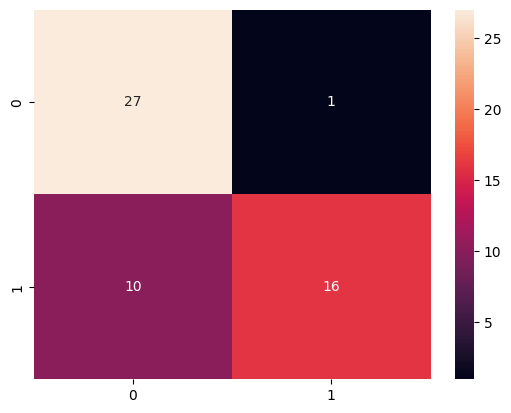

In [27]:
cm = confusion_matrix(test_dataset.classes, predictions)
sns.heatmap(cm, annot=True)

In [28]:
# The neural network can correctly identify 75% of the bart images and when it 
# identifies these bart images, it is correct 68% of the time
# We can conclude that this neural network is better for classifying bart images, as 
# we saw in the confusion matrix
print(classification_report(test_dataset.classes, predictions))

              precision    recall  f1-score   support

           0       0.73      0.96      0.83        28
           1       0.94      0.62      0.74        26

    accuracy                           0.80        54
   macro avg       0.84      0.79      0.79        54
weighted avg       0.83      0.80      0.79        54



### Save and load the model

In [ ]:
# This step is very important, because when you are satisfied with the results you 
# can save the model to use at another time (as the neural network training can take,
# there is no need to train the algori. Assuming you are a consultant to a company, 
# you create the neural network and send the weights to the developers to put the 
# neural network into production (a graphical interface could be made for example)

In [29]:
model_json = network.to_json()
with open('network.json','w') as json_file:
  json_file.write(model_json)

In [30]:
network_saved = save_model(network, '/content/weights.hdf5')

In [31]:
with open('network.json', 'r') as json_file:
  json_saved_model = json_file.read()
json_saved_model

'{"module": "keras", "class_name": "Sequential", "config": {"name": "sequential", "trainable": true, "dtype": {"module": "keras", "class_name": "DTypePolicy", "config": {"name": "float32"}, "registered_name": null}, "layers": [{"module": "keras.layers", "class_name": "InputLayer", "config": {"batch_shape": [null, 64, 64, 3], "dtype": "float32", "sparse": false, "ragged": false, "name": "input_layer", "optional": false}, "registered_name": null}, {"module": "keras.layers", "class_name": "Conv2D", "config": {"name": "conv2d", "trainable": true, "dtype": {"module": "keras", "class_name": "DTypePolicy", "config": {"name": "float32"}, "registered_name": null}, "filters": 32, "kernel_size": [3, 3], "strides": [1, 1], "padding": "valid", "data_format": "channels_last", "dilation_rate": [1, 1], "groups": 1, "activation": "relu", "use_bias": true, "kernel_initializer": {"module": "keras.initializers", "class_name": "GlorotUniform", "config": {"seed": null}, "registered_name": null}, "bias_initi

In [32]:
network_loaded = tf.keras.models.model_from_json(json_saved_model)
network_loaded.load_weights('weights.hdf5')
network_loaded.compile(loss = 'categorical_crossentropy', optimizer='Adam', metrics=['accuracy'])

In [33]:
network_loaded.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3137)           │     3,616,961 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3137)           │     9,843,906 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │         6,276 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,486,535 (51.45 MB)

 Trainable params: 13,486,535 (51.45 MB)

 Non-trainable params: 0 (0.00 B)

### Validate the model on new data - one single image

In [34]:
image = cv2.imread('/content/homer_bart_2/test_set/homer/homer15.bmp')

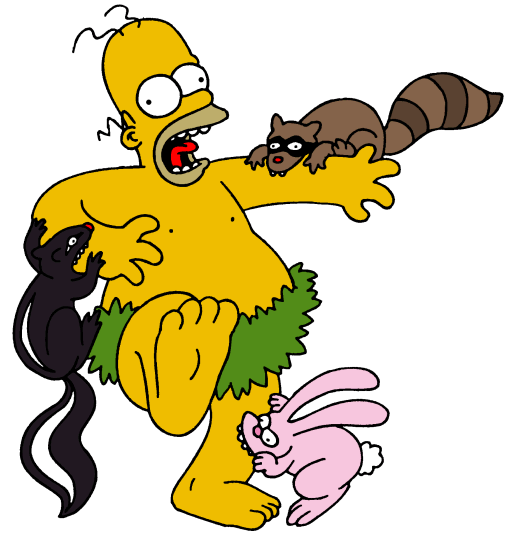

In [35]:
cv2_imshow(image)

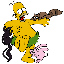

In [36]:
image = cv2.resize(image, (64, 64))
cv2_imshow(image)

In [37]:
image

array([[[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       ...,

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]]

In [38]:
# normalization of the pixel values to be between 0 and 1, which is a common practice in deep learning to improve the performance of the model
image = image / 255
image

array([[[1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.],
        ...,
        [1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.]],

       [[1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.],
        ...,
        [1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.]],

       [[1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.],
        ...,
        [1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.]],

       ...,

       [[1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.],
        ...,
        [1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.]],

       [[1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.],
        ...,
        [1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.]],

       [[1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.],
        ...,
        [1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.]]])

In [39]:
image.shape

(64, 64, 3)

In [40]:
image = image.reshape(-1, 64, 64, 3)
image.shape

(1, 64, 64, 3)

In [41]:
result = network_loaded(image)
result

<tf.Tensor: shape=(1, 2), dtype=float32, numpy=array([[4.1492896e-08, 1.0000000e+00]], dtype=float32)>

In [42]:
result = np.argmax(result)
result

np.int64(1)

In [43]:
test_dataset.class_indices

{'bart': 0, 'homer': 1}

In [44]:
if result == 0:
  print('Bart')
else:
  print('Homer')

Homer
